# 1. Setup

We will be writing and executing Python code in a Jupyter Notebook and editing and running it within Colab. **As some participants have work-issued laptops that do not allow using Google Colab, Kaggle can be used as a viable alternative.**

The Jupyter Notebook is an interactive environment for writing and running code. The .ipynb file extension is used for notebooks.

Colaboratory, or “Colab” for short, is a product from Google Research. Colab allows anybody to write and execute arbitrary python code through the browser, and is especially well suited to machine learning, data analysis and education. More technically, Colab is a hosted Jupyter notebook service that requires no setup to use, while providing free access to computing resources including GPUs.

So basically Colab allows you to write Python code and run it "in the cloud".  It saves your code, and you can import existing ipynb files and export them as well (to turn them in for grading).
A notebook may be downloaded in either a .ipynb or .py file from the menu option File | Download as. Choosing the .py option downloads a Python .py script, in which all rich output has been removed and the content of markdown cells have been inserted as comments.  Of course if a lab that you complete for this course requires you to write up a text answer to a question, remember to download the .ipynb file to turn in, and not just the .py file.

Open [Colab's intro webpage](https://colab.research.google.com/notebooks/intro.ipynb?utm_source=scs-index#scrollTo=5fCEDCU_qrC0) in a new window and read through the Getting Started and Data Science sections.  

Then, when you have time, click on "Overview of Colaboratory" and read through that page.  You can stop before the Magics section if desired.

As you already know, to upload a new ipynb file to Colab, just click on 'File'-> 'Upload Notebook' and search for the file you want to edit in Colab.


# 2. Classification

In this lab, you will explore a fundamental focus of machine learning - _classification_. We will walk through using various classification algorithms with different datasets.

Classification is a form of [supervised learning](https://wikipedia.org/wiki/Supervised_learning). Examples of classification problems are: identifying email as 'spam' or 'not spam' or determining if a tumor is malignant or benign. In particular, these are examples of binary classification where there are two possible outcomes. Outcomes can be described in pairs of 'positive'/'negative' such as 'yes'/'no', 'true'/'false' or '1'/'0'.


In contrast to binary classification, multiclass classification involves predicting among three or more classes or categories instead of just two. It extends the concept of classification to scenarios where there are multiple possible outcomes. For instance, identifying different species of flowers based on their features or classifying articles into various topics.

In this lab, both binary and multi-class classification will be covered.

## 2.1 Binary Classification

In this set of exercises, we will use the [Breast Cancer Wisconsin (Diagnostic) Data Set](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29). The dataset contains information on the disease status of 569 breast cancer patients: they were either diagnosed with a malign (status M) or with a benign (status B) tumor.

For each patient, the dataset also contains 30 features that represent statistics of the cell nuclei present in images taken after [fine needle aspirate tissue samples](https://en.wikipedia.org/wiki/Fine-needle_aspiration). These 30 features are the mean, standard deviation and the maximum of 10 measurements on the cell nuclei:
- radius
- texture
- perimeter
- area
- smoothness
- compactness
- concavity
- concave points
- symmetry
- fractal dimension

**Based on these feature of the cell nuclei, we would like to predict whether a patient has a malign or a benign breast cancer tumor.** Let's download the necessary packages and read in the data:

In [45]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install graphviz

In [46]:
!wget https://raw.githubusercontent.com/gdewael/teaching/main/UGAIN2021/wdbc.data

--2026-05-12 11:58:29--  https://raw.githubusercontent.com/gdewael/teaching/main/UGAIN2021/wdbc.data
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 124103 (121K) [text/plain]
Saving to: ‘wdbc.data.1’

wdbc.data.1         100%[===================>] 121.19K  --.-KB/s    in 0.02s   

2026-05-12 11:58:29 (7.33 MB/s) - ‘wdbc.data.1’ saved [124103/124103]



The data can be loaded within a pandas dataframe:

In [47]:
import pandas as pd
import numpy as np

data = pd.read_csv('./wdbc.data', header=None, index_col=0, names=['Patient ID', 'status'] + list(np.arange(1,31,1)))
status = data['status']
data.head()

,status,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
Patient ID,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


The status column within our dataframe contains information regarding the different classes we want to predict (either M for malign or B for benign). In classification tasks, it's crucial to pay attention to the distribution of the labels within the dataset. Class imbalance occurs when the number of instances in each class is not approximately equal. This situation is particularly common in real-world datasets, where certain classes may be significantly underrepresented compared to others.

Let's look at the distribution of the disease status:

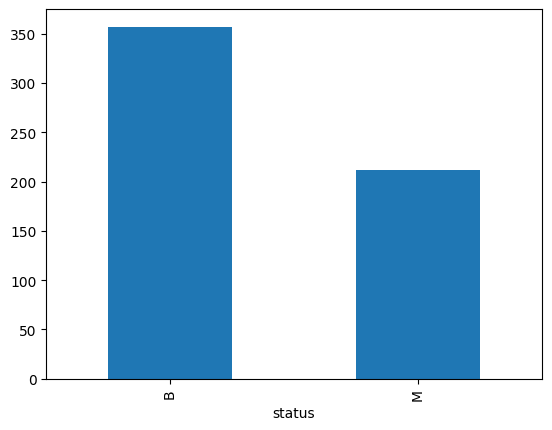

In [48]:
data['status'].value_counts().plot(kind='bar');

There are about 350 benign cases and roughly 200 malign cases. This is a fairly balanced dataset.
But it is important to consider the following when dealing with imbalanced datasets:
1. Model Bias: Imbalanced datasets can lead to biased models, where the model's predictive performance is skewed towards the majority class. This bias can result in poor generalization to the minority class, leading to suboptimal performance.

2. Misleading Accuracy: Accuracy, a commonly used metric for evaluating classification models, can be misleading in the presence of class imbalance. A model that predicts the majority class for every instance may achieve high accuracy, but it fails to capture the nuances of the minority class.

3. Cost-Sensitive Learning: In many real-world applications, misclassifying instances from the minority class can have higher costs or consequences compared to misclassifying instances from the majority class. Understanding class imbalance allows for the implementation of cost-sensitive learning techniques to mitigate such risks.

4. Decision-making: The ultimate goal of a classification model is often to support decision-making processes. Ignoring class imbalance can lead to biased decisions, especially in applications where the impact of different classes varies significantly.

Textual categorical labels pose a challenge for machine learning algorithms that require numerical input data. We will use in the lab algorithms from the [scikit-learn](https://scikit-learn.org/stable/) library, and they cannot directly process categorical labels. Therefore, a LabelEncoder can be used to transform categorical labels into numerical representations.

In [49]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder().fit(status)
encoder.classes_  # 'B' will become class 0, 'M' will become class 1

array(['B', 'M'], dtype=object)

With this encoder, we are now able to divide our original dataset in two, well-known, sets of data resource: a label set and a set of features.

In [50]:
y = encoder.transform(status)
X = data.drop('status', axis=1).values # Drop the disease status from the dataframe, convert to numpy array

### A first classification model

We are interested in creating a model that can determine if an observation/row/patient characterized by 𝐱 belongs to one of two possible classes, denoted by 𝑦. In other words, we want to model $P(y|\mathbf{x})$, also called the *class posterior* or the *class-membership probability*.

#### Logistic Regression (LR)
LR is the most fundamental example of a discriminative model. In simple words, logistic regression is a model that predicts the probability of an event taking place. Based on a decision boundary (e.g. 0.5), an LR model returns an outcome of 0 (Status = Benign) for probabilities less than that decision boundary and a prediction of 1 (Status = Malign) is returned for probabilities greater than or equal than the boundary:

In longer words:</br>
The hypothesis of logistic regression tends it to limit the cost function between 0 and 1. But instead of simpler linear models, like linear regression, LR does not model the mean of a continuous outcome, but the logarithm of the [odds](https://en.wikipedia.org/wiki/Odds) of the probability $P(X)$:

\begin{equation}
log \frac{P(y|\mathbf{x})}{1-P(y|\mathbf{x})} = w_{0}x_{0} + w_{1}x_{1} + ... + w_{p}x_{p} = \mathbf{w^Tx}
\end{equation}
This formula just explains traditional linear regression, involving the addtion of values of different features multiplied by some weights.

So LR doesn't directly tell us the chance of something happening. Instead, it tells us the odds of it happening.
But in practice,  we are really interested in the probability $P(y|\mathbf{x})$ and not in the odds of $P(y|\mathbf{x})$.
To obtain this from the previous equation, we apply the *logistic function* (otherwise called a *sigmoid* function):

\begin{equation}
\phi(z) = \frac{1}{1 + e^{-z}} = \frac{e^{z}}{1+e^{z}}
\end{equation}

Applying this function on both sides of the LR equation, we get a model for $P(y|\mathbf{x})$ as follows:

\begin{equation}
P(y|\mathbf{x}) = \phi(\mathbf{w^Tx}) = \frac{1}{1 + e^{-\mathbf{w^Tx}}}
\end{equation}

If we want to classify a data point $\mathbf{x}$, we can calculate the probability of it being class $y$ with the above equation. A final classification is then made by assigning it to the class if the probability $P(y|\mathbf{x})$ exceeds a certain threshold. A typical threshold is 0.5.

![sigmoid](https://miro.medium.com/v2/resize:fit:1000/1*A_D47lu42P_XLf8lzdhNQg.png)

<div class="alert alert-success">
<b> THOUGHT EXERCISE: What would happen to our predictions when we would choose a lower threshold, let's say 0.2? How would this affect the accuracy of our predictions? Can you think of a situation where we would want to do this? </b>
</div>

By changing the decision boundry to a lower threshold probabilities higher or equal to 0.2 will be classified as 'M'. One could be interested in this if the model is biased towards predicting 'B', to detect more true positives in the data. Be aware that when the treshold is lowered there is a chance of also labelling more 'B' cases as 'M'. However in a medical use case (e.g. breast cancer detection) it would be more "costly" to mark a patient as 'B' if they are 'M', than the other way around.

Let's train an LR classifier on our data. To indicate how good our model performs, we will evaluate our trained LR model on a part of the data that we kept aside during training. The classification accuracy (the percentage of samples predicted correctly) can be used to provide this comparison.

<div class="alert alert-success">

<b>EXERCISE: Using scikit-learn, split the data in an 80% training and a 20% test set. Fit a logistic regression model and evaluate training and testing accuracy. </b>
</div>

Use [this method](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) for train-test splitting and [this implementation](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to perform logistic regression. </br> Accuracy can be computed by using the score() method of each model.

In [51]:
# ** solution **
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000000)
lr_model.fit(X_train, y_train)

print(lr_model.score(X_train, y_train))
print(lr_model.score(X_test, y_test))

0.9626373626373627
0.956140350877193


The model's performance is determined by a random data split, which might be a behavior that we do not want. One way to avoid this is to perform [cross-validation](https://machinelearningmastery.com/k-fold-cross-validation/), we will return on this topic later in the course.


<div class="alert alert-success">
<b>EXERCISE: Use your LR model to predict the class probabilities $P(y|\mathbf{x})$ and the classes for the training data. Use the predict_proba() method to generate the predicted probabilities. Take note of the output shape of predict_proba(), what do the columns mean? The predict_proba() method returns a 2D array where each row corresponds to a data point and each column represents the probability of that data point belonging to a particular class. For binary classification, the first column represents the probability of the data point belonging to class 0, while the second column represents the probability of belonging to class 1. To specifically focus on the probability of the positive class (class 1), you need to select the second column using [:,1].
</br>
Use the code below to plot the two against each other. Which data points are most likely to be misclassified?</b>
</div>

In [52]:
predicted_class_probabilities = lr_model.predict_proba(X_train)[:,1]
predicted_classes = lr_model.predict(X_train)

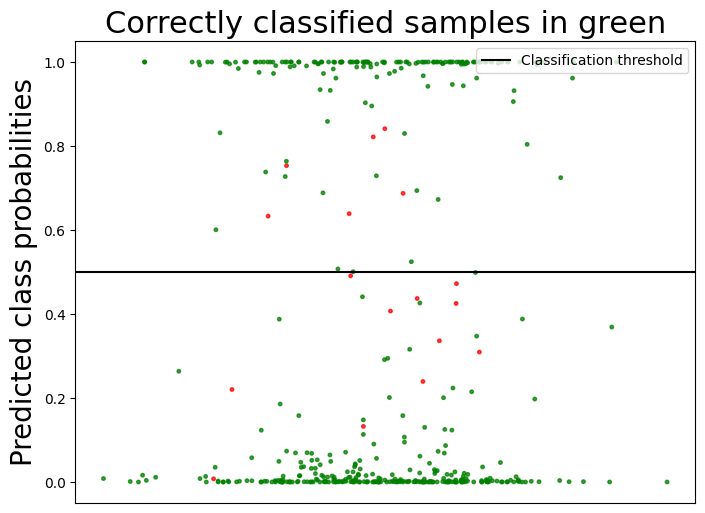

In [53]:
import matplotlib.pyplot as plt

try:
    misclassified = predicted_classes !=  y_train
    colors = ['red' if wrong else 'green' for wrong in misclassified ]
    fig, ax = plt.subplots(figsize=(8,6))
    test_jitter = np.random.normal(scale=0.1, size=len(predicted_class_probabilities))
    ax.scatter(test_jitter, predicted_class_probabilities,
               marker='.', s=25, color=colors, alpha=0.75)
    ax.get_xaxis().set_ticks([]);
    ax.set_ylabel('Predicted class probabilities').set_fontsize(20)
    ax.set_title('Correctly classified samples in green', size=22)
    ax.axhline(0.5, color="black", label="Classification threshold")
    ax.legend(loc='upper right')
    plt.show()
except:
    print("MISSING PROBABILITIES")

Clearly, the misclassified points are those points where the predicted probability of class membership is rather closer to 0.5.

We can also use other metrics to visualize the difference in predictions. One of such methods is a [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix). The confusion matrix helps you see how many prediction the model got right and also how many it got wrong. It lists the actual classes (like "Benign" or "Malign") along the top and the predicted classes (also "Benign" or "Malign") on the side, and each cell in the matrix shows how many patients belong to each group. It, therefore, also indicates the amount of predicted Benign that are actually Malign and vice versa. Basically, the confusion matrix gives you a clear picture of where the model is getting confused and making mistakes. A confusion matrix might look like this:
![confusion](https://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/8_confusion-matrix-python.jpg)

<div class="alert alert-success">
<b>EXERCISE: Calculate the Confusion Matrix for your LR model on the test set.</b>
</div>

You can use the following [code](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_model.predict(X_test))

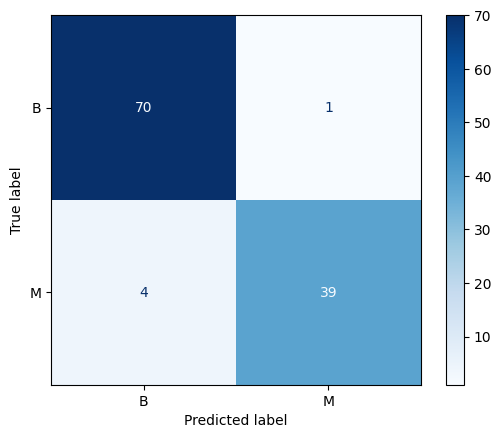

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
try:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_)
    disp.plot(cmap=plt.cm.Blues)
except:
    print("CM NOT DEFINED")

#### K-Nearest Neighbors (KNN)
K-Nearest Neighbors (KNN) is a simple, yet powerful non-parametric, instance-based learning algorithm used for both classification and regression tasks. It operates on the principle that similar data points exist close to each other in feature space.

The core idea is that when making a prediction for a new data point, the algorithm:
- Calculates the distance (commonly Euclidean) between the new point and all points in the training dataset.
- Selects the k nearest neighbors to the new point.
- Assigns the majority class among the k neighbors.

KNN does not build a model during training. Instead, it memorizes the training data and performs computation at inference time, which can be computationally expensive for large datasets.
![image](https://miro.medium.com/v2/resize:fit:1400/1*Ky6ofD04Z0axy5OJi4bCoA.png)

<div class="alert alert-success">
<b>EXERCISE: Train a KNeighborsClassifier with default parameters and evaluate its accuracy on the test set.</b>
</div>

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_model.score(X_test, y_test)

0.956140350877193

<div class="alert alert-success">
<b>EXERCISE: Evaluate how changing the number of neighbors affects performance. Use a loop to try k values from 1 to 20
 and lot test accuracy versus k. </b>
</div>


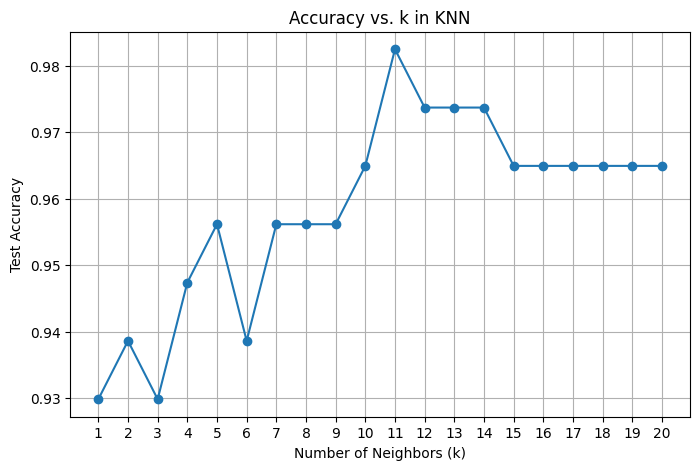

In [57]:
import matplotlib.pyplot as plt

k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    accuracies.append(knn_model.score(X_test, y_test))

if len(accuracies)>0:
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, accuracies, marker='o')
    plt.title("Accuracy vs. k in KNN")
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Test Accuracy")
    plt.grid(True)
    plt.xticks(k_range)
    plt.show()


We can also plot the confusion matrix for the test set results for this model:

<div class="alert alert-success">
<b>EXERCISE: Calculate the confusion matrix for the best possible k.</b>
</div>

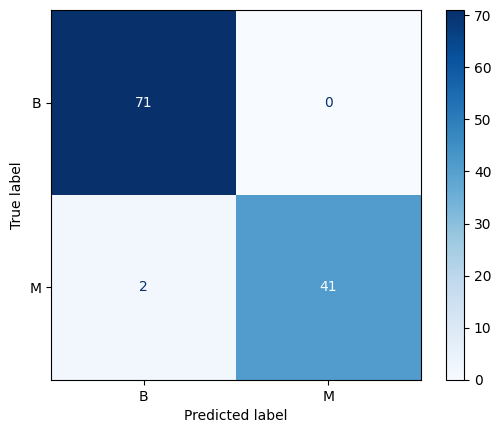

In [58]:
# Step 4: Confusion matrix

knn_best = KNeighborsClassifier(n_neighbors=11)
knn_best.fit(X_train, y_train)
cm = confusion_matrix(y_test, knn_best.predict(X_test))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
try:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_)
    disp.plot(cmap=plt.cm.Blues)
except:
    print("CM NOT DEFINED")

The concepts of *specificity* and *sensitivity* are better suited in this example dataset. These are *class-specific* metrics: the sensitivity is the fraction of (true) positives that is correctly identified (as positive). The specificity is the fraction of (true negatives) that is correctly classified (as negative).

![sensvsspec](https://blog.medisolv.com/hs-fs/hubfs/false%20negative.png?width=347&name=false%20negative.png)

<div class="alert alert-success">
<b>EXERCISE: Calculate the specificity and sensitivity for your KNN model on the test set, based on the above confusion matrix. You can use the ravel() method to obtain from the confusion matrix the true negatives, false positives, false negatives and true positives.</b>
</div>

In [59]:
TN, FP, FN, TP = confusion_matrix(y_test, knn_best.predict(X_test)).ravel()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"The sensitivity of the KNN model is {sensitivity} and the specificity is {specificity}")

The sensitivity of the KNN model is 0.9534883720930233 and the specificity is 1.0


A classifier might predict nearly every sample as positive, hence obtaining a high sensitivity but a very low specificity. One way to change this is to change the threshold for classification: by selecting a higher threshold, we will predict more samples as negatives, hence the sensitivity will go down because we will now predict some positives as being negative. However, the specificity will improve, because we now only predict samples as positive if the model outputs a higher probability for it being positive.

We can easily illustrate this effect by defining a different threshold on the predicted probabilities of the KNN model results.

In [60]:
threshold = 0.9
try:
    n_pred = (knn_best.predict_proba(X_test)[:,1]>threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, n_pred).ravel()
    sensitivity = tp / (tp+fn)
    specificity = tn / (tn+fp)

    print(f"The sensitivity of this threshold is {sensitivity} and the specificity is {specificity}")
except:
    print()

The sensitivity of this threshold is 0.7906976744186046 and the specificity is 1.0


Feel free to change or adapt the threshold to gain more insights.

Changing this threshold provides a lot of information regarding the predictive capabilities of the generated model. Therefore, metrics exist to automate this procedure and check every possible threshold. Evaluating the apparent trade-off between sensitivity and specificity can be performed by the receiver operating characteristic (ROC) curve. A ROC curve is a plot of the true positive rate (sensitivity) versus the false positive rate (one minus the specificity) for various thresholds. It typically looks like this:

![ROC](https://miro.medium.com/max/724/1*eFmiqjRi5MmZwfaPsy82yg.png)

It illustrates (visually) the trade-off between sensitivity and specificity as we vary the threshold. A good measure to evaluate a classifier is the **area under the ROC curve (AUROC or AUC)**. A classifier that does random guesses has an AUC of 0.5 (dotted line in the plot), so if we design a classifier for a certain problem we want it to achieve an AUC higher than 0.5.

Check this [blog](https://datascienceplus.com/interpretation-of-the-auc/) to read a bit more considering the interpretation of the AUROC.

<div class="alert alert-success">
<b>EXERCISE: Use the predicted probabilities from the test set to compute the ROC AUC score on the test dataset. Then, use the code below to plot the ROC curves of the LR model and the KNN model.</b>
</div>

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score

# Use test data!
predicted_class_probabilities_LR = lr_model.predict_proba(X_test)[:, 1]
AUC_LR = roc_auc_score(y_test, predicted_class_probabilities_LR)

predicted_class_probabilities_KNN = knn_best.predict_proba(X_test)[:, 1]
AUC_KNN = roc_auc_score(y_test, predicted_class_probabilities_KNN)

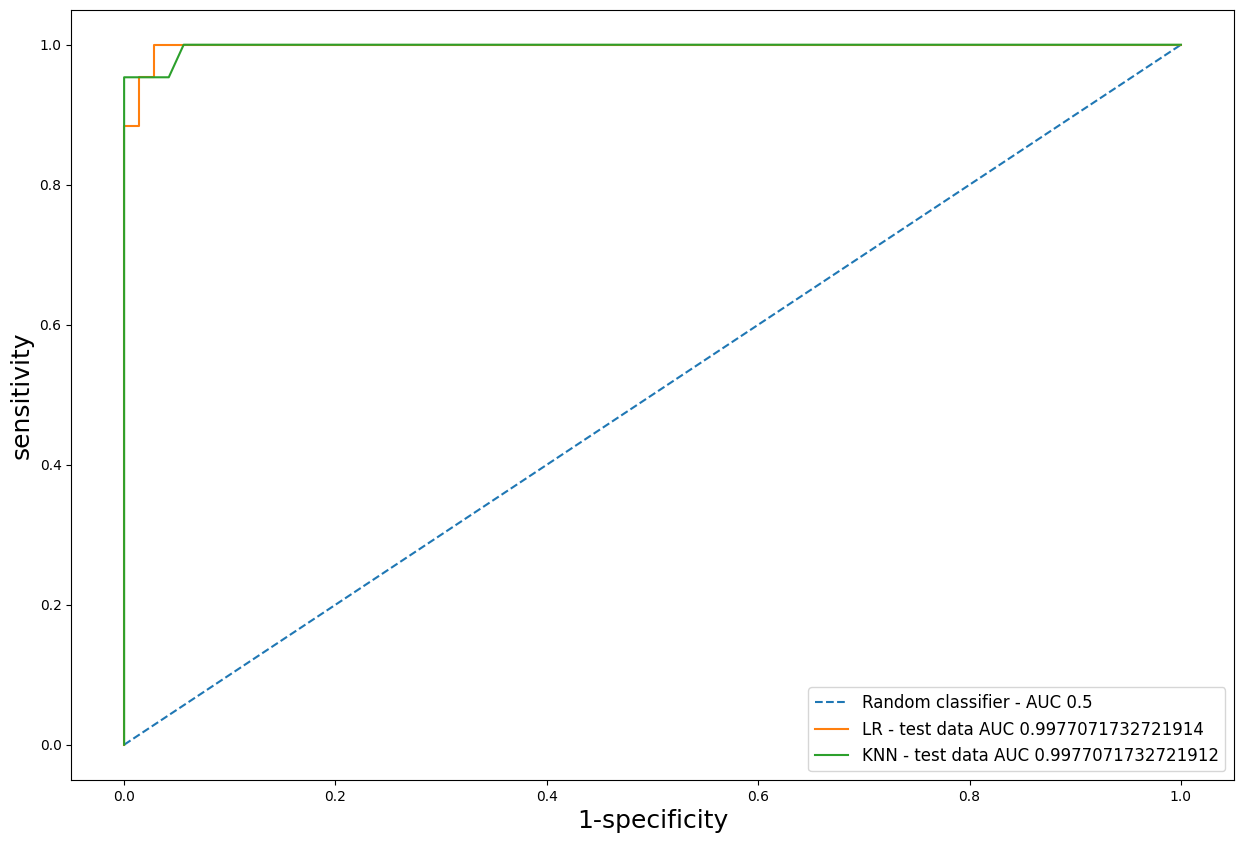

In [62]:

try:
    roc_LR = roc_curve(y_test, predicted_class_probabilities_LR)
    roc_dummy = roc_curve(y_test, predicted_class_probabilities_KNN)

    fig, ax = plt.subplots(figsize=(15,10))
    ax.plot([0, 1], [0, 1], '--')
    ax.plot(roc_LR[0], roc_LR[1])
    ax.plot(roc_dummy[0], roc_dummy[1])
    ax.set_xlabel('1-specificity').set_fontsize(18)
    ax.set_ylabel('sensitivity').set_fontsize(18)


    ax.legend(['Random classifier - AUC 0.5',
               'LR - test data AUC {}'.format(AUC_LR), 'KNN - test data AUC {}'.format(AUC_KNN),],
             fontsize='large')
    plt.show()
except:
    print("AUC_LR and AUC_KNN NOT DEFINED")

## 2.2 Multi-class Classification

As previously mentioned, while binary classification tasks focus on predicting one of two classes, multiclass classification introduces additional complexities, where the model must predict one of several possible outcomes. To illustrate these challenges, we will use the Covertype dataset. This dataset contains information about forest cover types, collected from cartographic variables representing different forest regions. The dataset includes seven distinct classes, each corresponding to a different type of forest cover, such as spruce-fir, lodgepole pine, or ponderosa pine. The goal of this classification task is to predict the type of forest cover based on 54 features, which include variables like elevation, slope, and soil type. This presents a more complex multiclass classification problem, requiring careful consideration of feature importance and model performance across multiple classes.

In [63]:
from sklearn.datasets import fetch_covtype

cov = fetch_covtype()
data = pd.DataFrame(data= np.c_[cov['data'], cov['target']], columns= cov['feature_names'] + ['target'])

<div class="alert alert-success">
<b>EXERCISE: Plot the distribution of the target classes. Are they balanced?</b>
</div>

<Axes: xlabel='target'>

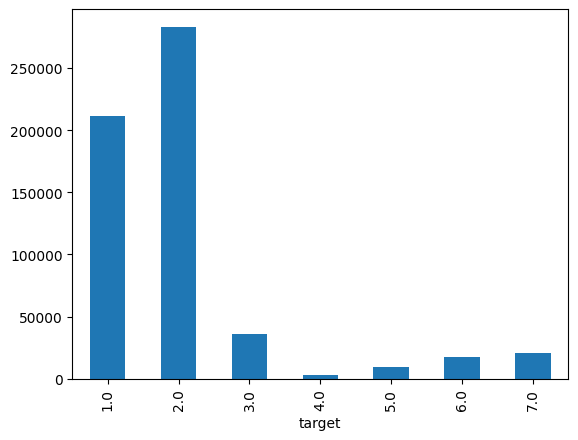

In [64]:
data['target'].value_counts().sort_index().plot(kind='bar')

We will again split the dataset into a train and a test set. Keep in mind that we don't need a label encoder here, as the target_column is already in a numerical format

In [65]:
#train-test split
X = data.drop('target',axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.1, random_state=42)

In principle, any classifier can be made multiclass using following methods:
1. **One-versus-one classification**
One-versus-one classification is another approach to a multiclass classification problem. For a K-class problem, the strategy consists of training $\frac{K(K-1)}{2}$ classifiers. Each of these classifiers must learn to distinguish two classes. Once the classifiers are trained, a voting scheme is applied to make a prediction for an unseen data point: each classifier has to decide between two possible classes. The final predicted class is the class that gets the largest number of votes.
2. **One-versus-all classification**
In one-versus-all (OvA) classification (also called one-versus-rest), a single classifier is trained per class, with the samples of that class as positive samples and all other samples as negatives.

However, some classifiers inherently support multiclass classification as part of their design, for example,  the KNeighborsClassifier is based on the majority vote of the k nearest training samples in the feature space, which naturally extends to multiclass settings. Each test sample is assigned to the class most common among its k nearest neighbors, making it straightforward to handle more than two classes.

In this part, we will explore another method that can handle multiclass classification by design: decision trees.

#### Decision Tree Classifier
A Decision Tree is a flowchart-like structure. For classification, it works by repeatedly splitting the dataset into subsets based on feature values that best separate the classes. Each leaf node of the tree corresponds to a predicted class.

In multiclass classification, the decision tree learns how to distinguish between more than two classes at once. It can naturally handle multiclass problems without the need for one-vs-one or one-vs-rest strategies.

<div class="alert alert-success">
<b>EXERCISE:  Train a Decision Tree Classifier on the Covertype dataset and evaluate its performance.
</br>You can use the scikit learn classification_report and confusion matrix
</div>

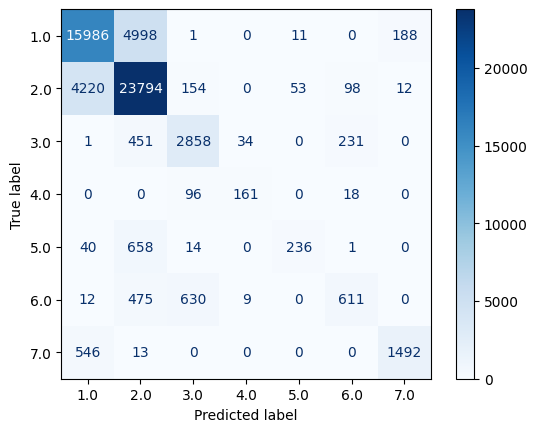

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

cm = confusion_matrix(y_test, dt_model.predict(X_test))

try:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(cmap=plt.cm.Blues)
except:
    print("CM NOT DEFINED")


<div class="alert alert-info">
<b> Visualize the trained Decision Tree and interpret it.
</br> - Let's use the `plot_tree` function to draw the structure of the decision process.
</br> - You can look at which features are used for splits and how the tree arrives at its predictions.
</div>

In [67]:
!pip install graphviz

In [68]:
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display

try:
    dot_data = export_graphviz(
        dt_model,
        out_file=None,
        feature_names=X.columns,
        class_names=[str(i) for i in sorted(y.unique())],
        filled=True,
        rounded=True,
        special_characters=True
    )

    graph = graphviz.Source(dot_data)

    graph.render(view=False)
    display(graph)

except Exception as e:
    print("Missing data:", e)

#### Bagging and boosting
We have seen that a single decision tree can be a powerful and intuitive model for classification or regression tasks. It is easy to interpret and fast to train. However, using only one decision tree has its limitations—it can overfit the training data, or it might be unstable, giving very different results with slight changes in the data.

To overcome these drawbacks, we turn to ensemble methods such as Bagging and Boosting. These techniques combine many decision trees to build a model that is more accurate, more stable, and often more generalizable than any single tree.

![bagging and boosting](https://pluralsight2.imgix.net/guides/81232a78-2e99-4ccc-ba8e-8cd873625fdf_2.jpg)

As illustrated in the image, Bagging builds several models in parallel using different random subsets of the training data (sampled with replacement), helping to reduce variance and prevent overfitting by averaging out the errors of individual models. Boosting, on the other hand, builds models sequentially, where each new model focuses more on the data points that were misclassified by the previous ones, effectively reducing bias and improving accuracy. In both methods, the final prediction is made by combining the outputs of all models, either through majority vote, averaging, or weighted sums.

Although decision trees are commonly used as base learners due to their simplicity and high variance (which ensembles can exploit), these techniques can be applied to other model types as well, such as neural networks or support vector machines.

<div class="alert alert-success">
<b>EXERCISE: Use Bagging with Decision Trees to improve performance.
</br>
- Use `BaggingClassifier` from `sklearn.ensemble` with `DecisionTreeClassifier` as the base estimator.
</br>
- Compare the confusion matrix on the test set with the single decision tree results
</br>
</b>
</div>

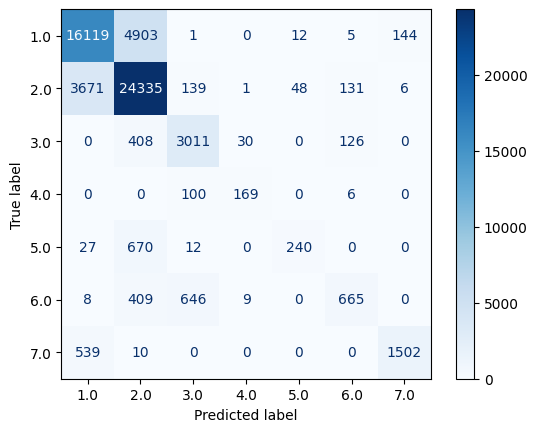

In [69]:
from sklearn.ensemble import BaggingClassifier

base = DecisionTreeClassifier(max_depth=10, random_state=42)

bagging_model = BaggingClassifier(estimator=base, random_state=42)
bagging_model.fit(X_train, y_train)

cm = confusion_matrix(y_test, bagging_model.predict(X_test))

try:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(cmap=plt.cm.Blues)
except:
    print("CM NOT DEFINED")

<div class="alert alert-success">
<b>EXERCISE: Use Boosting with Decision Trees to improve performance.
</br>
- Use `AdaBoostClassifier` from `sklearn.ensemble` with `DecisionTreeClassifier` as the base estimator.
</br>
- Compare the confusion matrix on the test set with the bagging approach
</br>
</b>
</div>

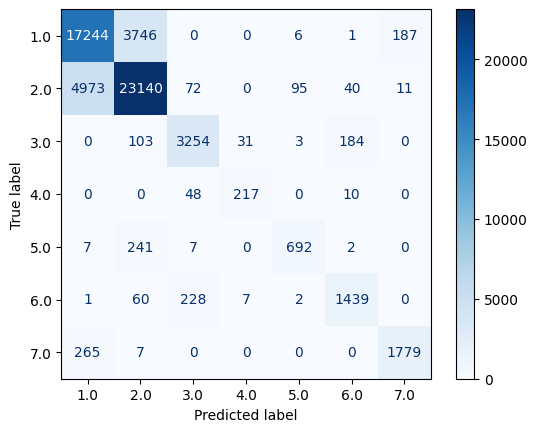

In [70]:
from sklearn.ensemble import AdaBoostClassifier

base = DecisionTreeClassifier(max_depth=10, random_state=42)

boosting_model = AdaBoostClassifier(estimator=base, random_state=42)
boosting_model.fit(X_train, y_train)

cm = confusion_matrix(y_test, boosting_model.predict(X_test))

try:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(cmap=plt.cm.Blues)
except:
    print("CM NOT DEFINED")



# 3 [OPTIONAL EXTRA] Another Dataset
**We've provided an additional exercise within this lab based on a new dataset: [Job change analytics](https://www.kaggle.com/arashnic/hr-analytics-job-change-of-data-scientists).**
<div class="alert alert-success">
<b>OPTIONAL EXCERCICE: Implement the data exploration and model construction pipeline for this dataset by reusing code from previous exercises. The goal of this exercise is to show that every dataset has its own unique set of characteristics and challenges.</b>
</b>
</div>
Some information about the dataset: A company which is active in Big Data and Data Science wants to hire data scientists among people who successfully pass some courses which conduct by the company. Many people signup for their training. Company wants to know which of these candidates really want to work for the company after training or looking for a new employment because it helps to reduce the cost and time as well as the quality of training or planning the courses and categorization of candidates. Information related to demographics, education, experience are in hands from candidates signup and enrollment. </br>
<b>Hence, the input features are details about persons who took data science courses, and the output of interest (target) is whether those persons are actually looking for a new job.</b>

More information [here](https://www.kaggle.com/arashnic/hr-analytics-job-change-of-data-scientists).

- What do you do with missing values in the dataset?: You can throw samples with at least one missing feature value out, or you can [impute](https://scikit-learn.org/stable/modules/impute.html) those missing values.
- What about class imbalance?
- Many features are categorical, how will you encode these?

Since there is no single right way to answer the above questions, we will not provide a solution to this exercise. Experiment at free will! If you have any questions, you can always mail the teaching assistant.

Below is some <u>preliminary</u> data exploration. Use this to further explore the data and make design choices.

In [71]:
!wget https://raw.githubusercontent.com/gdewael/teaching/main/UGAIN2021/HR_analytics.csv

--2026-05-12 12:08:37--  https://raw.githubusercontent.com/gdewael/teaching/main/UGAIN2021/HR_analytics.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1961145 (1.9M) [text/plain]
Saving to: ‘HR_analytics.csv.1’

HR_analytics.csv.1  100%[===================>]   1.87M  --.-KB/s    in 0.04s   

2026-05-12 12:08:37 (52.3 MB/s) - ‘HR_analytics.csv.1’ saved [1961145/1961145]



In [72]:
data = pd.read_csv('HR_analytics.csv', index_col='enrollee_id')
data.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
enrollee_id,,,,,,,,,,,,,
8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [73]:
# number of NaN (missing values) per feature:
pd.isnull(data).sum(0)

,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938
company_type,6140


In [74]:
# number of unique values per feature:
for k in data.columns:
    print(k, len(np.unique(data[k][~pd.isnull(data[k])])))

city 123
city_development_index 93
gender 3
relevent_experience 2
enrolled_university 3
education_level 5
major_discipline 6
experience 22
company_size 8
company_type 6
last_new_job 6
training_hours 241
target 2


In [75]:
# Look at what the unique values are for a specific feature:
feature = 'enrolled_university'
np.unique(data[feature][~pd.isnull(data[feature])])

array(['Full time course', 'Part time course', 'no_enrollment'],
      dtype=object)

In [76]:
print("YOUR CODE HERE")

YOUR CODE HERE


# 4 [OPTIONAL EXTRA] Text inputs (example with DNA)

Since machine learning models expect numbers as inputs, not words, we need to do some preprocessing first to make them compatible with ML models. A very common feature representation for text sequences is called the **Bag of Words**. It consists of listing all the possible tokens that might occur in your text. A token might be one word, or a combination of two or multiple words. The feature representation is then a matrix with the count of the tokens for each text instance. The simplest transformation is to just look at the counts of individual tokens: the 1-grams. However, it might be interesting to count combinations of two or more words as well. Consider the following example, where we have 2 example input sample sentences:

In [77]:
from sklearn.feature_extraction.text import CountVectorizer

data = ['this is real life',
       'is this real life']
print('data:\n', data[0], '\n', data[1])
vectorizer = CountVectorizer(analyzer='word', ngram_range=(1,2))

analyze = vectorizer.build_analyzer()
print('vocabulary:\n', analyze(data[0]))

features = vectorizer.fit_transform(data)
print('final feature representation:\n', features.toarray())

data:
 this is real life 
 is this real life
vocabulary:
 ['this', 'is', 'real', 'life', 'this is', 'is real', 'real life']
final feature representation:
 [[1 1 0 1 1 1 1 1 0]
 [1 0 1 1 1 1 1 0 1]]


Note that by default, the vectorizer returns the features as a sparse array: in most applications, each row of the feature matrix will contain a lot of zeros. For this exercise, you can convert it to a regular numpy array with the ```toarray()``` method.

If we restrict ourselves to look at 1-grams, both sentences above are transformed into the exact same feature representation. However, suppose we want to do sentiment analysis and classify whether a sentence contains a question or not. Then it might be useful to look at bigrams as well, as above

In [78]:
vectorizer = CountVectorizer(analyzer='word', ngram_range=(1,1))
analyze = vectorizer.build_analyzer()
analyze(data[0])
features = vectorizer.fit_transform(data)
print('Only 1-grams:')
print('final feature representation:\n', features.toarray())

Only 1-grams:
final feature representation:
 [[1 1 1 1]
 [1 1 1 1]]


When we consider bigrams, the feature representation for both sentences is no longer exactly the same. Maybe the features that represent 'this is' and 'is this' could be helpful here.

Still the bag-of-words features completely ignores where every n-gram was in the sentence. Another way to take this into account is to assign $v$ dummy features for every location in the sentence, with $v$ being the vocabulary size (number of possible different words). Every first, second, third and fourth word get assigned 1 feature for every possible word in that location (out of 4 possible words in the vocabulary). This is called [one-hot encoding](https://en.wikipedia.org/wiki/One-hot#Natural_language_processing)
This requires the sentences to be all the same length, for example, 4 words as in the 2 sentences above.

In [79]:
data_splitwords = [sentence.split(' ') for sentence in data]
print('data split by words:')
print(data_splitwords)
vocab = list(set([word for sentence in data_splitwords for word in sentence]))
print('vocabulary:')
print(vocab)
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore',
                    categories=[vocab]*len(data_splitwords[0]))

features = enc.fit_transform(data_splitwords)
print('resulting feature representation:')
print(features.toarray())

data split by words:
[['this', 'is', 'real', 'life'], ['is', 'this', 'real', 'life']]
vocabulary:
['life', 'real', 'this', 'is']
resulting feature representation:
[[0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0.]]


If it is not immediately clear what the features mean in this example: the first four features represent which word is the first word in each sentence. The first and sentence has as first word 'this', this is the last word in the vocabulary, so of the first four features, the last is given by $1$. The second sentence has 'is' as the first word, which is the second word in the vocabulary, for this reason, the second column of the first four features is given by $1$ for this sentence. Both sentences have the same last two words 'real life', it can be seen that the last 8 features for both sentences are identical.

Armed with these encoding schemes, we can tackle a real problem. **DNA sequences** as inputs are peculiar because they are essentially text: following an alphabet containing only A, T, C or G. We will use data from a published [study](https://bmcbiol.biomedcentral.com/articles/10.1186/1741-7007-12-4) about sigma factors in E. coli. Some biological background information for those interested:

> The binding region of the transcription unit,  commonly called the promoter region, is known to play a key role  in the transcription rate of downstream genes. In Eubacteria, the sigma factor ($\sigma$) binds with the RNA  polymerase subunit ($\alpha\beta\beta'\omega$) to create RNA polymerase. Being part of the RNA polymerase holoenzyme, the sigma element acts as the connection between RNA polymerase and DNA. Depending on the sigma factor bound to the transcription unit, different binding regions of the enzyme with the DNA are observed. The data represents specific DNA regions of the *E. coli* genome to which one or more sigma factors bind.

In less-biological-jargon words: certain molecules called sigma factors control activity of genes, they do so by binding to the DNA close to the gene. If we can predict for an input DNA sequence if such a molecule will bind, we gain an understanding in the biological function of those genes and molecules.

The dataset contains 4724 DNA sequences. For each sequence, we have information on five target variables, each representing 5 sigma factors. Each time, the outcome is binary, indicating whether the sigma factor binds to the sequence or not. This is a **multi-label** problem, where an input can belong to any (multiple at once) of the classes, as opposed to only one possible class for each sample in multi-class. For simplicity in this exercise, we will focus only on one class: RPOD.

In [80]:
!wget https://raw.githubusercontent.com/gdewael/teaching/main/UGAIN2021/promotor_list_exp_growth.csv
promotor_data = pd.read_csv('./promotor_list_exp_growth.csv', index_col=0)
promotor_data.head(20)

X = np.array(promotor_data.PROBE_SEQUENCE)
y = promotor_data['RPOD'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

--2026-05-12 12:08:38--  https://raw.githubusercontent.com/gdewael/teaching/main/UGAIN2021/promotor_list_exp_growth.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 315440 (308K) [text/plain]
Saving to: ‘promotor_list_exp_growth.csv.1’

promotor_list_exp_g 100%[===================>] 308.05K  --.-KB/s    in 0.02s   

2026-05-12 12:08:38 (13.8 MB/s) - ‘promotor_list_exp_growth.csv.1’ saved [315440/315440]



<div class="alert alert-success">

<b> OPTIONAL EXTRA EXERCISE:
Use one of the encoding schemes to preprocess the DNA data. Construct a model and evaluate performance on the test set. Play around with different preprocessing values, and keep testing performances. What types of preprocessing lead to good performance for this dataset? In what cases are we overfitting? Think about fair evaluation: if we keep testing out configurations and evaluating on the test set, is our final test performance estimate fair? We can solve this by keeping an additional data split separate: training, validation and testing. Then we test different hyperparameters (different ways of preprocessing) on the validation set. We don't touch the test set until we have our final model. This is the only fair way of evaluating. For more information, see this [link](https://en.wikipedia.org/wiki/Training,_validation,_and_test_sets).</b>
</div></b>
</div>

In [81]:
# ** solution **
# N-GRAM features:

vectorizer = CountVectorizer(analyzer='char', ngram_range=(1,5))

X_train1 = vectorizer.fit_transform(X_train).toarray()
X_test1 = vectorizer.transform(X_test).toarray()

KNNmodel = KNeighborsClassifier()
KNNmodel.fit(X_train1, y_train)

y_pred = KNNmodel.predict(X_test1)
y_pred_train = KNNmodel.predict(X_train1)

print(roc_auc_score(y_test, y_pred), roc_auc_score(y_train, y_pred_train))


# LOCATION features:

X_train2 = [list(x) for x in X_train]
X_test2 = [list(x) for x in X_test]

enc = OneHotEncoder(categories=[['A', 'T', 'C', 'G']]*len(X_train2[0]))

X_train2 = enc.fit_transform(X_train2).toarray()
X_test2 = enc.fit_transform(X_test2).toarray()

KNNmodel = KNeighborsClassifier()
KNNmodel.fit(X_train2, y_train)

y_pred = KNNmodel.predict(X_test2)
y_pred_train = KNNmodel.predict(X_train2)

print(roc_auc_score(y_test, y_pred), roc_auc_score(y_train, y_pred_train))
# ** solution **

0.5389745796372303 0.7052966717481182
0.6038329140738778 0.7604616607448973
